<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_9_2_Hotel_Cancellations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation — Classification Project
**Author:** Brad Sheese

---

### Learning Objectives
By the end of this notebook you will be able to:
1. Apply the full classification workflow to a new dataset with moderate class imbalance and real feature engineering challenges (data leakage, high-cardinality categoricals).
2. Generate out-of-fold (OOF) probabilities on training data to select thresholds without contaminating the test set.
3. Interpret the cost-optimal threshold in the context of operational constraints.
4. Run nested cross-validation with `StratifiedKFold` and interpret the resulting AUC scores as a generalization estimate.
5. Explain the decision to omit `scale_pos_weight` based on the dataset's class balance, connecting to the three-strategy framework from notebook 6.

In [ ]:
# Business Cost Configuration
COST_FN = 120.0  # unexpected cancellation (missed revenue)
COST_FP = 40.0   # overbooked guest (compensation + reputation)

**Dataset:**
* [Hotel Booking Demand (Antonio, Almeida & Nunes, 2019)](https://www.sciencedirect.com/science/article/pii/S2352340918315191?via%3Dihub)
* 119,390 reservations, 32 features, binary target (cancelled or not).


## The Business Problem


A hotel group loses revenue from last-minute cancellations — empty rooms that could have been sold.
They also risk overbooking: accepting more reservations than rooms, then compensating bumped guests.

**Goal:** Predict which reservations will be cancelled so the hotel can adjust overbooking limits, send reminders, or re-sell rooms.

**Cost structure:**
* **FN (unexpected cancellation):** empty room costs ~EUR 120 in lost revenue
* **FP (overbooked guest):** compensation + reputation damage costs ~EUR 40
* Ratio: FN is ~3x more expensive than FP. The optimal threshold should be lower than 0.5.


---
# 1. Load and Explore the Data



## 1.1 Download and Initial Inspection


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests

url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'
file_name = 'hotels.csv'

# Check if the file already exists locally
if not os.path.exists(file_name):
    print(f'Downloading {file_name} from {url}...')
    response = requests.get(url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f'{file_name} downloaded successfully.')
else:
    print(f'{file_name} already exists locally.')

# Load the DataFrame from the local file
df = pd.read_csv(file_name)

# Frequency-based grouping for agent and company
for col in ['agent', 'company']:
    df[col] = df[col].fillna(0).astype(int).astype(str)
    top_10 = df[col].value_counts().nlargest(10).index
    df.loc[~df[col].isin(top_10), col] = 'Other'

print('Shape:', df.shape)
df.head(3)

hotels.csv downloaded successfully.
Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Cleaning
`company` and `agent` have many missing values. Rather than dropping them, we preserve the top 10 most frequent IDs and group the rest into an "Other" category — keeping valuable signal from major travel agents and corporate accounts.

Other features with a small number of missing values (`children`, `country`) are handled inline in the cell below.

In [30]:
# Handling missing values in numerical columns if any
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')


## 1.2 Target Distribution and the Accuracy Paradox


In [8]:
target_counts = df['is_canceled'].value_counts()
print('Target distribution:'); print(target_counts)
cancel_rate = df['is_canceled'].mean()
print('Cancellation rate: {:.3f}'.format(cancel_rate))
naive_baseline = max(target_counts) / len(df)
print('Naive baseline accuracy: {:.3f}'.format(naive_baseline))
print('A model that always predicts not cancelled achieves {:.1f}% accuracy.'.format(naive_baseline*100))


Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Cancellation rate: 0.370
Naive baseline accuracy: 0.630
A model that always predicts not cancelled achieves 63.0% accuracy.


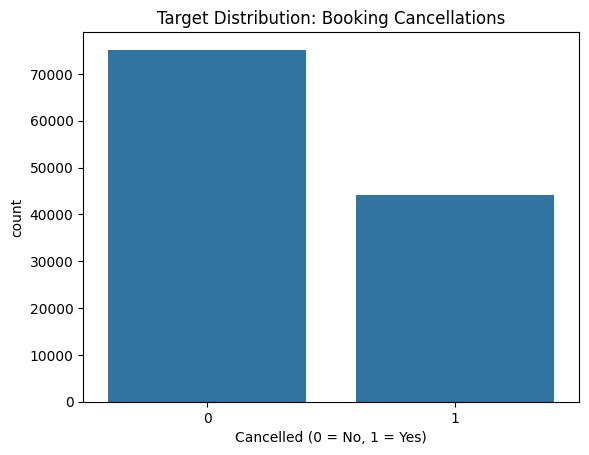

In [9]:
sns.countplot(data=df, x='is_canceled')
plt.title('Target Distribution: Booking Cancellations')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.show()


## 1.3 Data Preparation


### Dropping Data Leakage and Overly Specific Features

`reservation_status` and `reservation_status_date` directly encode the cancellation outcome (e.g., "Check-Out" means the guest arrived). Including them would leak the target into the features — a classic data leakage error.

`assigned_room_type` reflects the room assigned at or after check-in. Since this is determined after the guest arrives, it can indirectly reveal the outcome (e.g., an upgrade suggests the guest actually showed up). We drop it to keep the model realistic.

`arrival_date_year` and `arrival_date_day_of_month` are dropped because they are unlikely to generalize: the year is fixed to the training period and the day-of-month is too granular to capture meaningful patterns.

`arrival_date_week_number` is kept because it captures finer-grained seasonality (e.g., holiday weeks, event periods) that the month alone cannot provide.


In [10]:
leakage_cols = ['reservation_status', 'reservation_status_date', 'arrival_date_year', 'arrival_date_day_of_month', 'assigned_room_type']
df_clean = df.drop(columns=leakage_cols)
print('Original columns:', len(df.columns))
print('After dropping leakage:', df_clean.shape[1])


Original columns: 32
After dropping leakage: 25


In [11]:
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print('Categorical features:', len(categorical_cols))
print('Total features:', len(numeric_cols) + len(categorical_cols))


Categorical features: 10
Total features: 24


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
num_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])
preprocessor = ColumnTransformer(transformers=[('num', num_pipe, numeric_cols), ('cat', cat_pipe, categorical_cols)])
print('Preprocessing pipeline ready.')


Preprocessing pipeline ready.


---
# 2. XGBoost Baseline Model



We split with `stratify=y` to preserve the same cancellation rate (~37%) in both training and test sets. Without stratification, a random split could by chance produce a test set with a very different class balance, making evaluation unreliable.

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', len(X_train), 'Test:', len(X_test))
print('Train cancellation rate: {:.3f}'.format(y_train.mean()))


Train: 95512 Test: 23878
Train cancellation rate: 0.370


### Model Configuration

This dataset has a ~37% cancellation rate — much closer to balanced than the credit card fraud (0.17%) or bank marketing (11.7%) datasets. At this level of imbalance:

- **No `scale_pos_weight` needed.** The class ratio is roughly 1.6:1 (non-cancelled to cancelled). XGBoost handles this with default settings; `scale_pos_weight = 1.7` would have negligible effect.
- **No custom objective.** Our cost ratio (FN=$120 / FP=$40 = 3:1) is modest. Threshold tuning after training is the cleanest approach at this cost ratio.
- **`eval_metric='logloss'`** monitors training and produces well-calibrated probabilities — appropriate for subsequent threshold tuning.

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])
pipe_xgb.fit(X_train, y_train)
print('XGBoost trained.')


XGBoost trained.


In [ ]:
# =====================================================================
# OUT-OF-FOLD PROBABILITIES FOR THRESHOLD TUNING
# =====================================================================
from sklearn.model_selection import cross_val_predict
print("Generating OOF probabilities (may take a moment)...")
oof_proba = cross_val_predict(pipe_xgb, X_train, y_train, cv=5, method='predict_proba')[:, 1]
print("Done. OOF probabilities will be used for all threshold tuning in Section 5.")

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = pipe_xgb.predict(X_test)

# Naive Strategy: Assume No Cancellations
fn_n = y_test.sum()
fp_n = 0
cost_naive = (fn_n * COST_FN) + (fp_n * COST_FP)

# Model Strategy (Threshold 0.5)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
cost_model = (fn * COST_FN) + (fp * COST_FP)

print(f'Cost of "Always No" strategy:  EUR {cost_naive:,.2f}')
print(f'Cost of XGBoost Model (0.5): EUR {cost_model:,.2f}')
print(f'Utility Improvement:         EUR {cost_naive - cost_model:,.2f}')


Cost of "Always No" strategy:  EUR 1,060,920.00
Cost of XGBoost Model (0.5): EUR 257,800.00
Utility Improvement:         EUR 803,120.00


## 2.1 Feature Importance


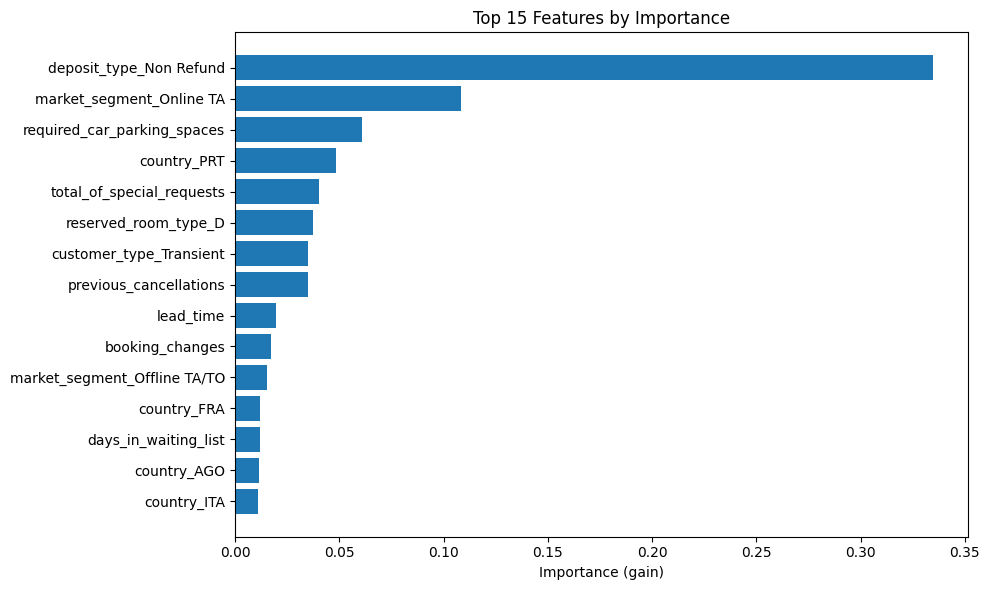

In [16]:
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(categorical_cols)
all_names = list(numeric_cols) + list(cat_names)
importance = pipe_xgb.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_names, 'importance': importance}).sort_values('importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feat_imp.tail(15)['feature'], feat_imp.tail(15)['importance'])
plt.xlabel('Importance (gain)'); plt.title('Top 15 Features by Importance')
plt.tight_layout(); plt.show()

# The top features are dominated by lead_time, deposit_type, and booking_changes — all intuitive.
# Longer lead times give more opportunity for plans to change, non-refundable deposits reduce cancellations,
# and booking changes often signal uncertainty. The hotel indicator (Resort Hotel) also appears, suggesting
# cancellation patterns differ between resort and city hotels.


### Interpreting Feature Importance

The plot above shows the top 15 features by gain-based importance (how much each feature contributes to reducing the model's loss). `lead_time` is the strongest predictor: longer booking horizons leave more room for cancellations. `deposit_type` is also critical — guests who pay a non-refundable deposit are far less likely to cancel. `booking_changes`, `market_segment`, and `hotel` type all carry meaningful signal. These insights are actionable: the hotel could target high-risk segments (e.g., long lead time, no deposit) with early re-marketing or flexible rebooking offers.

---
# 3. Confusion Matrix and Basic Metrics


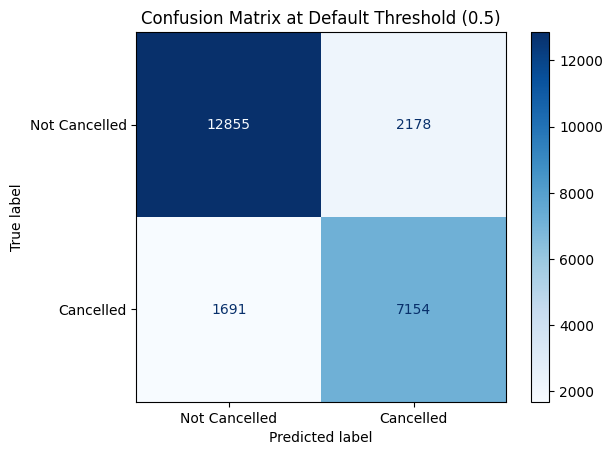

True Negatives:   12855 (correctly predicted stay)
False Positives:   2178 (overbooked guests)
False Negatives:   1691 (unexpected cancellations!)
True Positives:    7154 (correctly predicted cancellation)


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Cancelled','Cancelled']).plot(cmap='Blues')
plt.title('Confusion Matrix at Default Threshold (0.5)'); plt.show()
tn, fp, fn, tp = cm.ravel()
print('True Negatives:  {:>6} (correctly predicted stay)'.format(tn))
print('False Positives: {:>6} (overbooked guests)'.format(fp))
print('False Negatives: {:>6} (unexpected cancellations!)'.format(fn))
print('True Positives:  {:>6} (correctly predicted cancellation)'.format(tp))


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
print('Precision: {:.4f}'.format(precision_score(y_test, y_pred)))
print('Recall:    {:.4f}'.format(recall_score(y_test, y_pred)))
print('F1-Score:  {:.4f}'.format(f1_score(y_test, y_pred)))
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Cancelled','Cancelled']))

# Interpretation notes:
# - 'macro avg': unweighted average across both classes. Treats the minority class equally.
# - 'weighted avg': average weighted by class support. Better reflects overall performance.
# - Here, the hotel cares most about the 'Cancelled' class (recall = 0.81).


Precision: 0.7666
Recall:    0.8088
F1-Score:  0.7871

Full Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.88      0.86      0.87     15033
    Cancelled       0.77      0.81      0.79      8845

     accuracy                           0.84     23878
    macro avg       0.83      0.83      0.83     23878
 weighted avg       0.84      0.84      0.84     23878



---
# 4. ROC Curve and AUC


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


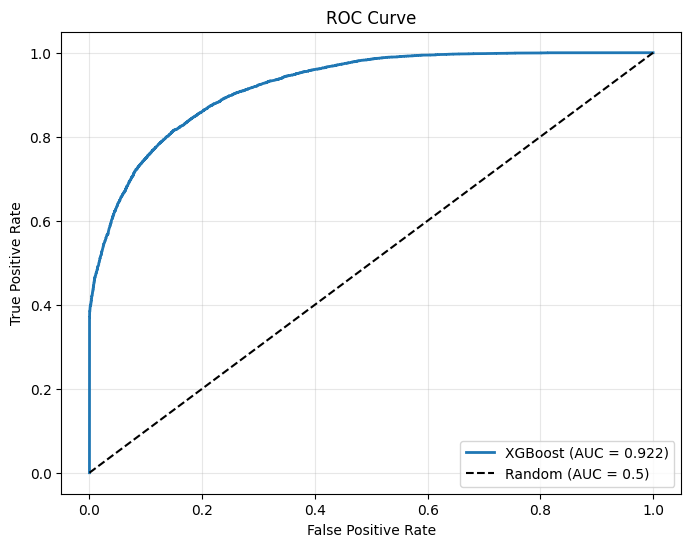

AUC = 0.922


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
y_proba = pipe_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.3f})'.format(roc_auc), linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.grid(alpha=0.3); plt.show()
print('AUC = {:.3f}'.format(roc_auc))

# AUC measures rank discrimination: probability that a random cancellation
# scores higher than a random non-cancellation.

### Precision-Recall Curve

While the ROC curve shows overall discrimination (TPR vs. FPR across all thresholds), the Precision-Recall (PR) curve focuses specifically on how well the model identifies the positive class — in this case, cancellations. PR curves are especially informative when the positive class is the minority or is the primary business concern, both of which apply here. Note that the PR curve uses a different baseline: instead of 0.5 (like ROC), the baseline equals the prevalence of the positive class (0.370). The PR AUC of 0.890 substantially exceeds this baseline, confirming the model adds real value for identifying cancellations.

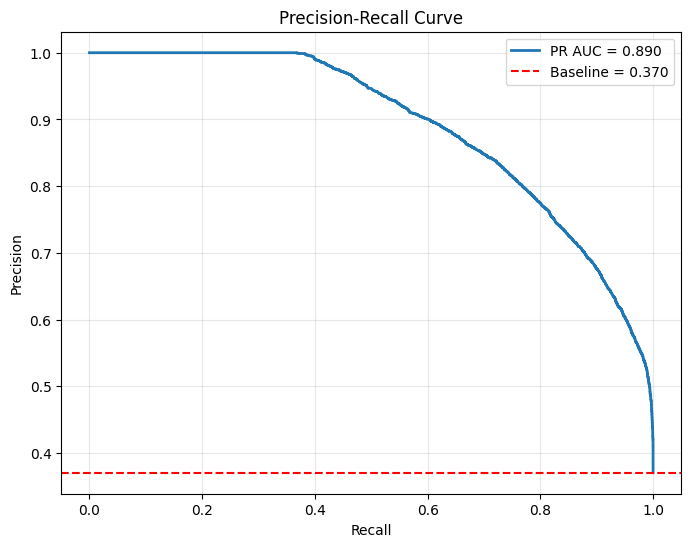

PR AUC = 0.890 (baseline = 0.370)


In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label='PR AUC = {:.3f}'.format(pr_auc), linewidth=2)
plt.axhline(y=y_test.mean(), color='r', ls='--', label='Baseline = {:.3f}'.format(y_test.mean()))
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve')
plt.legend(); plt.grid(alpha=0.3); plt.show()
print('PR AUC = {:.3f} (baseline = {:.3f})'.format(pr_auc, y_test.mean()))


---
# 5. Threshold Tuning


The default 0.5 threshold assumes equal cost. For a hotel:
* **FN (unexpected cancellation):** lost room revenue (defined as `COST_FN`)
* **FP (overbooked guest):** compensation + reputation cost (defined as `COST_FP`)

The 3:1 FN/FP ratio means the optimal threshold is typically below 0.5.

All thresholds in this section are selected using **out-of-fold (OOF) probabilities on the training set** (computed above). The test set is reserved for final evaluation only.

## 5.1 Youden's J Statistic

Youden's J identifies the threshold maximising the model's ability to distinguish cancellations from non-cancellations. It is defined as J = TPR − FPR (or equivalently, Sensitivity + Specificity − 1). It is a useful default when costs are unknown or equal.

With a 37%/63% class split — much closer to balanced than the credit card fraud dataset — Youden's J will typically produce a threshold near 0.5. This makes intuitive sense: when class prevalence is close to equal, the TPR vs. FPR trade-off is most balanced near the default threshold.

As with all threshold tuning in this series, the optimal value is computed on OOF training probabilities to avoid test-set contamination.

In [21]:
from sklearn.metrics import roc_curve
# Use OOF training probabilities — NOT test-set probabilities
fpr_oof, tpr_oof, thresh_oof = roc_curve(y_train, oof_proba)
youden_j = tpr_oof - fpr_oof
best_idx = np.argmax(youden_j)
best_thresh_youden = thresh_oof[best_idx]
print("Youden's J optimal threshold (from training OOF): {:.4f}".format(best_thresh_youden))
print('TPR: {:.4f}, FPR: {:.4f}'.format(tpr_oof[best_idx], fpr_oof[best_idx]))

# Evaluate on test set
y_pred_youden = (y_proba >= best_thresh_youden).astype(int)
print('Test set — Precision: {:.4f}, Recall: {:.4f}'.format(
    precision_score(y_test, y_pred_youden), recall_score(y_test, y_pred_youden)))

Youden's J optimal threshold: 0.4920
TPR: 0.8159, FPR: 0.1501
Precision: 0.7618
Recall:    0.8159


## 5.2 Business Cost Sensitivity


In [22]:
# Sweep candidate thresholds on OOF training probabilities
candidate_thresholds = np.linspace(0.01, 0.99, 200)
oof_costs = []
for thresh in candidate_thresholds:
    yh = (oof_proba >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_train, yh).ravel()
    oof_costs.append(fn_t * COST_FN + fp_t * COST_FP)

best_cost_idx = np.argmin(oof_costs)
best_thresh_cost = candidate_thresholds[best_cost_idx]
print('Cost-optimal threshold (from training OOF): {:.4f}'.format(best_thresh_cost))

# Evaluate on test set
y_pred_cost = (y_proba >= best_thresh_cost).astype(int)
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test, y_pred_cost).ravel()
print('Test set cost at this threshold: EUR {:,.0f}'.format(fn_c * COST_FN + fp_c * COST_FP))

Cost-optimal threshold: 0.3892
Minimum cost: EUR 257800 on 23,878 test samples


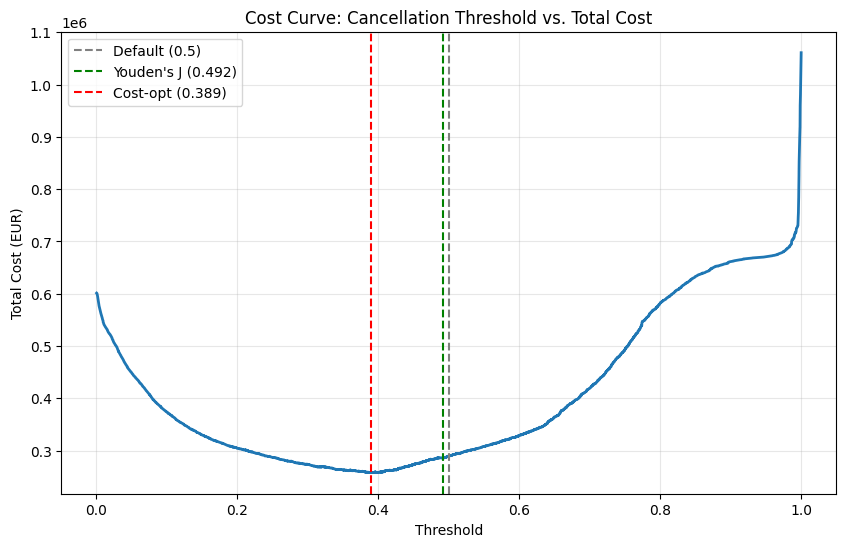

In [23]:
plt.figure(figsize=(10,6))
plt.plot(candidate_thresholds, oof_costs, linewidth=2, label='Training OOF Cost Curve')
plt.axvline(x=0.5, color='gray', ls='--', label='Default (0.5)')
plt.axvline(x=best_thresh_youden, color='green', ls='--',
    label="Youden's J ({:.3f})".format(best_thresh_youden))
plt.axvline(x=best_thresh_cost, color='red', ls='--',
    label='Cost-opt ({:.3f})'.format(best_thresh_cost))
plt.xlabel('Threshold'); plt.ylabel('Total Cost (EUR)')
plt.title('Cost Curve: Tuned on Training OOF Data')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [24]:
# Evaluate all strategies on the held-out TEST SET
def eval_thresh(y_true, y_proba, thresh, label):
    y_p = (y_proba >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, y_p).ravel()
    prec = precision_score(y_true, y_p, zero_division=0)
    rec  = recall_score(y_true, y_p)
    cost = fn_t * COST_FN + fp_t * COST_FP
    return {"Strategy": label, "Threshold": f"{thresh:.4f}",
            "Precision": f"{prec:.3f}", "Recall": f"{rec:.3f}",
            "Test Cost (EUR)": f"{cost:,.0f}", "_cost": cost}

rows = [
    eval_thresh(y_test, y_proba, 0.50, "Default (0.50)"),
    eval_thresh(y_test, y_proba, best_thresh_youden, f"Youden's J ({best_thresh_youden:.3f})"),
    eval_thresh(y_test, y_proba, best_thresh_cost, f"Cost-Optimal ({best_thresh_cost:.3f})"),
]
display_rows = [{k: v for k, v in r.items() if k != "_cost"} for r in rows]
print("=== Threshold Strategy Comparison on Test Set ===")
import pandas as pd
display(pd.DataFrame(display_rows))

best_c = min(r["_cost"] for r in rows)
print(f"\nBest strategy saves EUR {rows[0]['_cost'] - best_c:,.0f} vs default threshold.")

Threshold comparison on test set:
  Default (0.5):       P=0.767 R=0.809 F1=0.787
  Youden (0.492): P=0.762 R=0.816 F1=0.788
  Cost-opt (0.389): P=0.672 R=0.904 F1=0.771


---
# 6. Nested Cross-Validation and Final Model


## 6.1 Nested Cross-Validation


When we tune hyperparameters using the same data that we evaluate on, performance metrics become optimistically biased — we are essentially peeking at the test set through the tuning process.

Nested cross-validation solves this by separating tuning from evaluation into two loops:
* **Outer loop** (5 folds): splits the data into training and holdout sets.
* **Inner loop** (3 folds): within each outer training fold, `GridSearchCV` finds the best hyperparameters.

The model tuned on the inner loop is then evaluated on the outer holdout fold, producing an honest, unbiased estimate of generalization performance.

Hyperparameters being tuned: `n_estimators`, `max_depth`, `learning_rate`.
AUC is used as the scoring metric because it is threshold-independent and works well for both balanced and moderately imbalanced datasets, unlike accuracy (which would be dominated by the majority class) or F1 (which depends on a chosen threshold).


In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
}
inner_grid = GridSearchCV(pipe_xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Running nested CV (5 outer x 3 inner x 8 combos)...')
nested_scores = cross_val_score(inner_grid, X, y, cv=outer_cv, scoring='roc_auc', n_jobs=-1)
print('Nested CV AUC:', nested_scores)
print('Mean AUC: {:.4f} +/- {:.4f}'.format(nested_scores.mean(), nested_scores.std()))
print('This is the honest, unbiased performance estimate.')

Running nested CV (5 outer x 3 inner x 8 combos)...
Nested CV AUC: [0.91102621 0.90663387 0.90455653 0.90575614 0.90525095]
Mean AUC: 0.9066 +/- 0.0023
This is the honest, unbiased performance estimate.


## 6.2 Final Production Model


The final model trains on 100% of data with optimal hyperparameters.
This is the model that gets deployed.


In [ ]:
print('Training final production model on 100% of data...')
final_grid = GridSearchCV(pipe_xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0, refit=True)
final_grid.fit(X, y)
print('Best params:', final_grid.best_params_)
print('Best CV AUC: {:.4f}'.format(final_grid.best_score_))
# Do NOT evaluate this model on X — it was just trained on X.
# The honest performance estimate is the nested CV mean above.

In [ ]:
# Use the cost-optimal threshold derived from OOF training data in Section 5.
print('Production threshold: {:.4f}'.format(best_thresh_cost))
print('Flag any reservation with P(cancel) >= {:.4f} for intervention.'.format(best_thresh_cost))
print()
print('Honest performance estimate:')
print('  Nested CV mean AUC = {:.4f} +/- {:.4f}'.format(nested_scores.mean(), nested_scores.std()))
print('  (Report nested CV score — do not evaluate the final model on its training data.)')

---
# Summary


This notebook demonstrated the complete 18_1 classification workflow on the Hotel Booking dataset:

| Concept | Section |
|---|---|
| Accuracy Paradox & Naive Baseline | 1.2 |
| Data Preparation & Leakage Prevention | 1.3 |
| XGBoost with Business Utility Analysis | 2 |
| Feature Importance | 2.1 |
| Confusion Matrix (TP/TN/FP/FN) | 3 |
| Precision, Recall, F1-Score | 3 |
| Classification Report (macro vs. weighted) | 3 |
| ROC Curve & AUC | 4 |
| Precision-Recall Curve | 4 |
| Youden's J Statistic | 5.1 |
| Business Cost Sensitivity | 5.2 |
| Cost Curve & Threshold Selection | 5.2 |
| Hyperparameter Grid Search | 6.1 |
| Nested Cross-Validation | 6.1 |
| Final Production Model | 6.2 |

**Business takeaways:**
* The cost-optimal threshold is below 0.5, reflecting the higher cost of an unexpected cancellation.
* Nested CV provides the honest performance estimate for real-world deployment.
* The final model can be used to adjust overbooking levels based on predicted cancellation probability.